## After running main.py we will analyze the results

In [10]:
# In your Jupyter notebook

import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

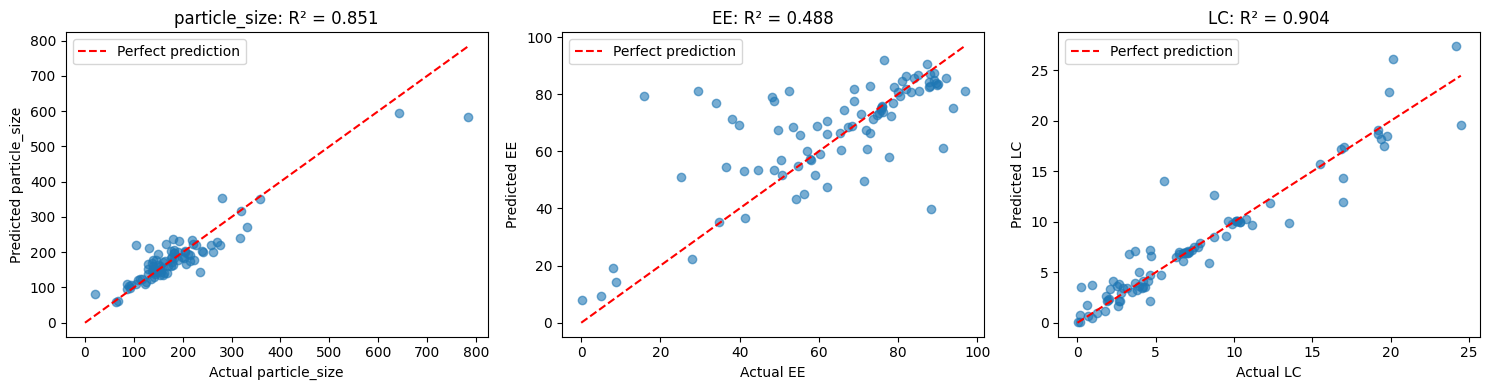

In [13]:
# Load the processed data from the notebook-relative path.
# This assumes the notebook is located in the `notebooks/` folder.
csv_path = Path('..') / 'data' / 'processed' / 'df13_with_features.csv'
df13 = pd.read_csv(csv_path)

# Load the trained models from the project `models/` folder.
model_root = Path('..') / 'models'
models = {
    'particle_size': joblib.load(model_root / 'particle_size_model.pkl'),
    'EE': joblib.load(model_root / 'EE_model.pkl'),
    'LC': joblib.load(model_root / 'LC_model.pkl')
}

# Load results
results = joblib.load(model_root / 'results.pkl')

# Visualize predictions vs actual
# This chart compares actual vs predicted values for:
# - particle_size
# - encapsulation efficiency (EE)
# - loading capacity (LC)
# The red dashed line is the perfect prediction line (y = x).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, target in enumerate(['particle_size', 'EE', 'LC']):
    axes[idx].scatter(results[target]['true_values'], 
                      results[target]['predictions'], 
                      alpha=0.6)
    axes[idx].plot([0, max(results[target]['true_values'])], 
                   [0, max(results[target]['true_values'])], 
                   'r--', label='Perfect prediction')
    axes[idx].set_xlabel(f'Actual {target}')
    axes[idx].set_ylabel(f'Predicted {target}')
    axes[idx].set_title(f'{target}: R² = {results[target]["test_r2"]:.3f}')
    axes[idx].legend()
plt.tight_layout()
plt.show()